In [1]:
import matplotlib.pyplot as plt 
import pandas as pd 

In [2]:
data_sheet_path = r"C:\Users\varch\OneDrive\Desktop\market simulation\stock_simulation_results.xlsx"

In [3]:
data = pd.read_excel(data_sheet_path)
data.head()

,time,event,event_state,trend,panic,volatility,liquidity,ewma_price,value_signal,retail_demand,contrarian_demand,momentum_demand,institutional_demand,value_demand,total_demand,price
0,0,no_event,0.0,0.000000,0.016667,0.0750,10000.0000,100.0000,0.0,0,0,0.0,0,0,0.0,99.9987
1,1,no_event,0.0,-0.000031,0.010010,0.0450,9991.6667,99.9999,0.0,0,0,0.0,0,0,0.0,99.9995
2,2,no_event,0.0,0.000018,0.006000,0.0270,9987.4948,99.9999,0.0,0,0,0.0,0,0,0.0,99.9990
3,3,no_event,0.0,-0.000012,0.003604,0.0162,9985.7453,99.9999,0.0,0,0,0.0,0,0,0.0,99.9985
4,4,no_event,0.0,-0.000012,0.002226,0.0100,9985.3688,99.9998,0.0,0,0,0.0,0,0,0.0,99.9997


In [4]:
data.columns.tolist()

['time',
 'event',
 'event_state',
 'trend',
 'panic',
 'volatility',
 'liquidity',
 'ewma_price',
 'value_signal',
 'retail_demand',
 'contrarian_demand',
 'momentum_demand',
 'institutional_demand',
 'value_demand',
 'total_demand',
 'price']

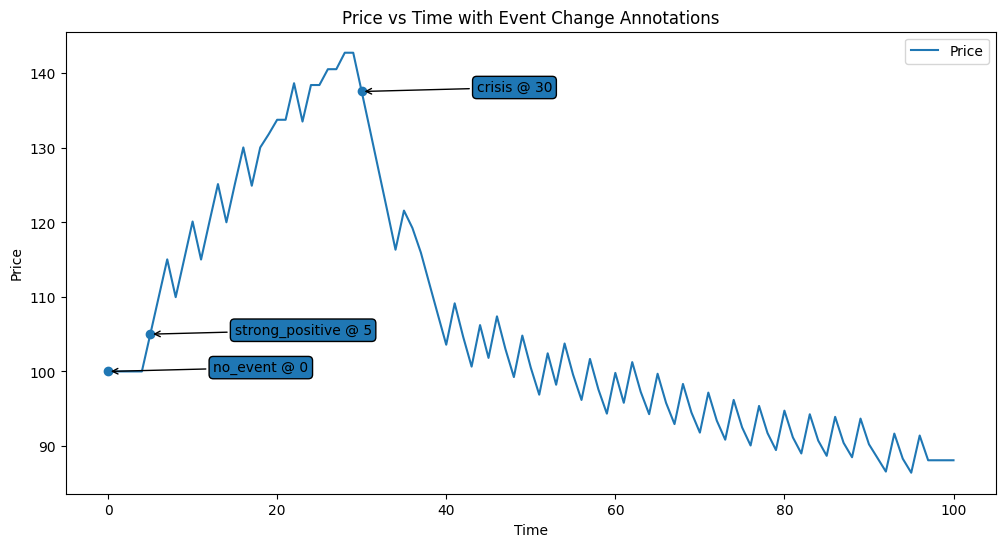

In [5]:
data['event_change'] = data['event'] != data['event'].shift(1)
changes = data[data['event_change']]

plt.figure(figsize=(12, 6))
plt.plot(data['time'], data['price'], label='Price')

# Highlight change points
plt.scatter(changes['time'], changes['price'])


# Annotate change points
for i, (_, row) in enumerate(changes.iterrows()):
    label = f"{row['event']} @ {row['time']}"
    
    offset = 15 if i % 2 == 0 else -25  # alternate up/down

    plt.annotate(
        label,
        (row['time'], row['price']),
        textcoords="offset points",
        xytext=(110, 0),
        ha='center',
        bbox=dict(boxstyle="round,pad=0.3"),
        arrowprops=dict(arrowstyle="->")
    )

# Labels and display
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Price vs Time with Event Change Annotations')
plt.legend()

plt.show()

